In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from image_utils     import ImageUtils
from preprocessor    import FingerprintPreprocessor
from skeletonizer    import Skeletonizer
from skeleton_repair import SkeletonRepair
from minutiae        import MinutiaeExtractor

preprocessor = FingerprintPreprocessor()
skeletonizer = Skeletonizer()
repairer     = SkeletonRepair()
extractor    = MinutiaeExtractor()


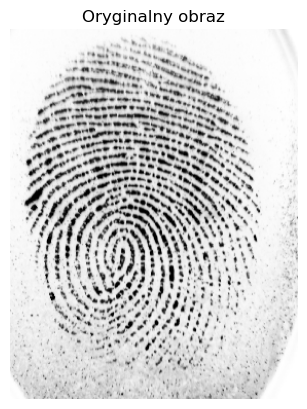

In [2]:
IMAGE_PATH = "fingerprints/w5.bmp"  
image = Image.open(IMAGE_PATH)

plt.imshow(image, cmap='gray')
plt.title('Oryginalny obraz')
plt.axis('off')
plt.show()


## Segmentacja (maska ROI)

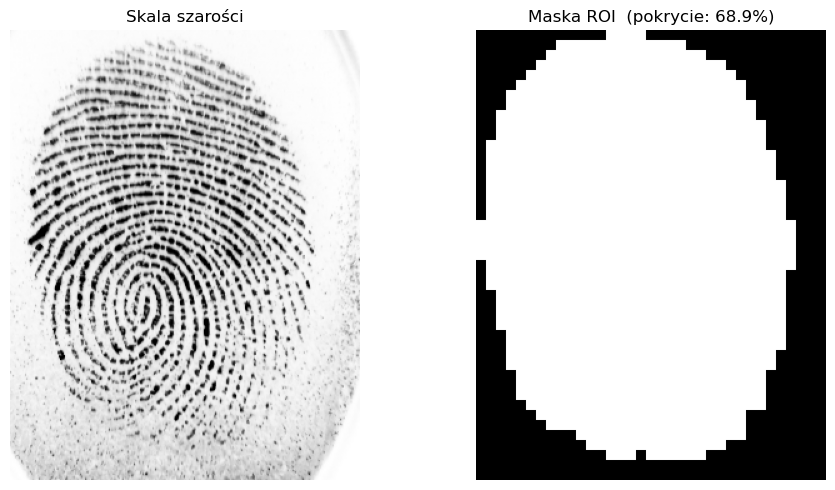

In [3]:

gray = ImageUtils.to_gray_pil(image)
mask = preprocessor.segment(gray, block_size=8, t_factor=0.3, margin=8)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Skala szarości')
axes[0].axis('off')
axes[1].imshow(mask, cmap='gray')
axes[1].set_title(f'Maska ROI  (pokrycie: {mask.sum()/mask.size*100:.1f}%)')
axes[1].axis('off')
plt.tight_layout()
plt.show()


## Normalizacja i CLAHE

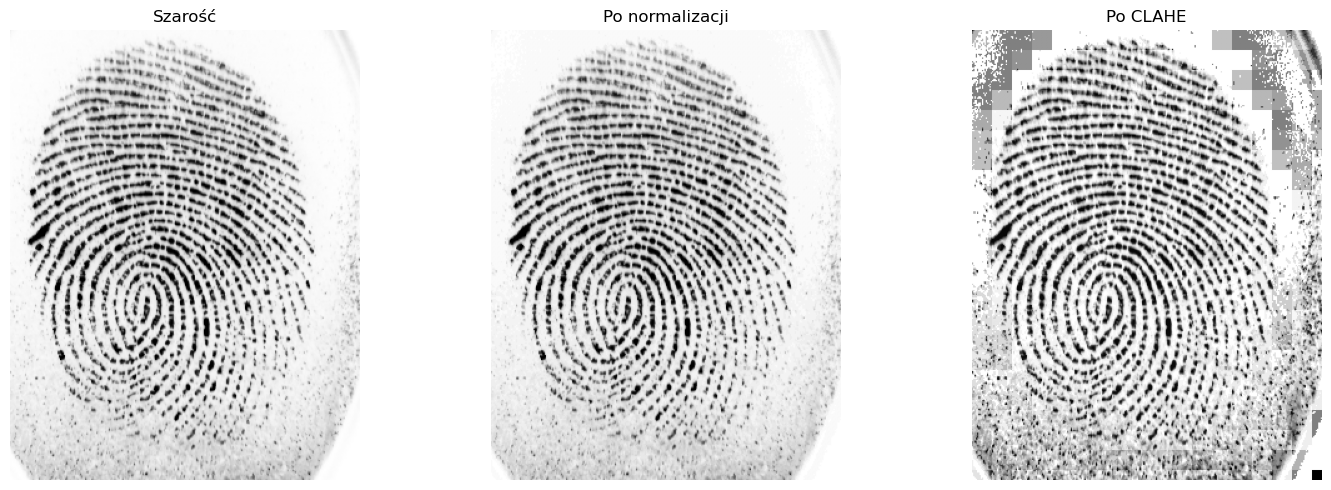

In [4]:
norm  = preprocessor.normalize(gray, m0=100, v0=100)
clahe = preprocessor.clahe(norm, clip_limit=3.0, tile_size=16)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img, title in zip(axes,
        [gray, norm, clahe],
        ['Szarość', 'Po normalizacji', 'Po CLAHE']):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()


##  Wzmocnienie Gaborem i binaryzacja

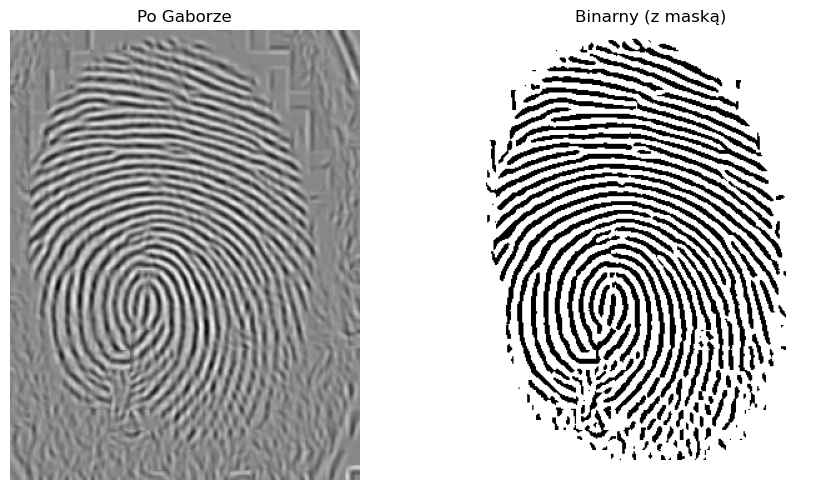

In [5]:
# Gabor na pełnym CLAHE (bez maskowania przed filtrem).
# Maskowanie przed Gaborem tworzy ostry brzeg → Gabor wykrywa go jako grzbiet → czarna obwódka.
# Maska nakładana dopiero na wynik binarny.
enhanced = preprocessor.gabor_enhance(clahe, freq=0.1, sigma=3.0, n_angles=16)
binary   = 255 - preprocessor.binarize(enhanced)
binary[mask == 0] = 255

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, img, title in zip(axes,
        [enhanced, binary],
        ['Po Gaborze', 'Binarny (z maską)']):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()


##  Szkieletyzacja

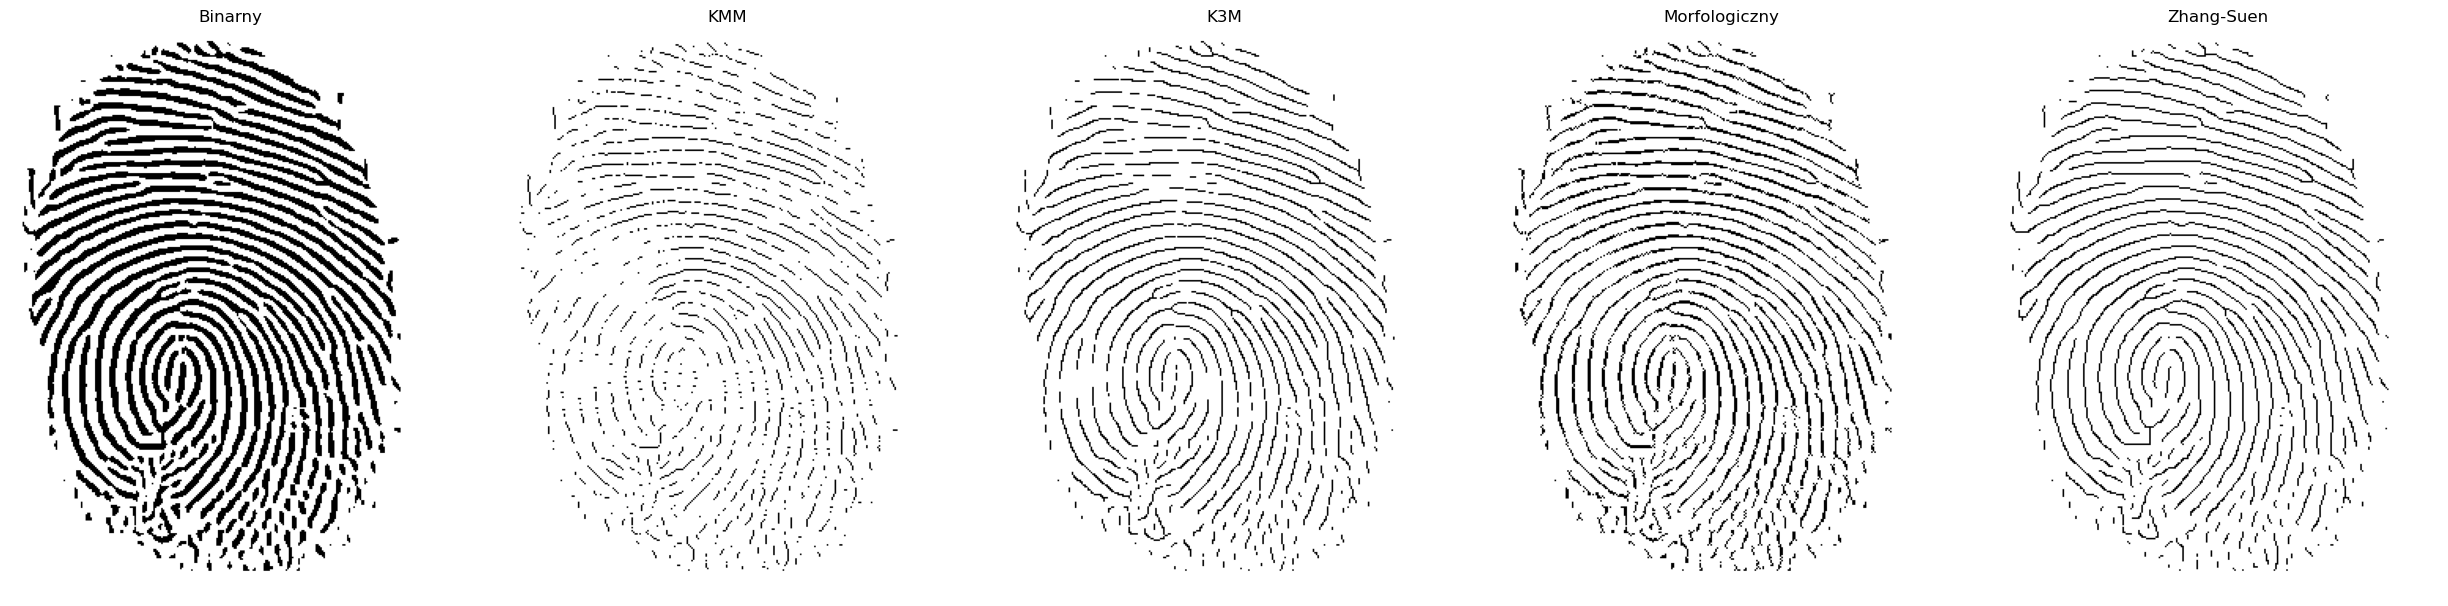

In [6]:
skeleton_kmm   = skeletonizer.kmm(binary)   
skeleton_k3m   = skeletonizer.k3m(binary)           
skeleton_morph = skeletonizer.morphological(binary) 
skeleton_zhang   = skeletonizer.zhang_suen(binary)

sk_kmm_01   = (skeleton_kmm   == 0).astype(np.uint8)
sk_k3m_01   = (skeleton_k3m   == 0).astype(np.uint8)
sk_morph_01 = (skeleton_morph == 0).astype(np.uint8)
sk_zhang_01 = (skeleton_zhang == 0).astype(np.uint8)

fig, axes = plt.subplots(1, 5, figsize=(25, 6))
for ax, img, title in zip(axes,
        [binary, skeleton_kmm, skeleton_k3m, skeleton_morph, skeleton_zhang],
        ['Binarny', 'KMM', 'K3M', 'Morfologiczny', 'Zhang-Suen']):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Naprawa szkieletu

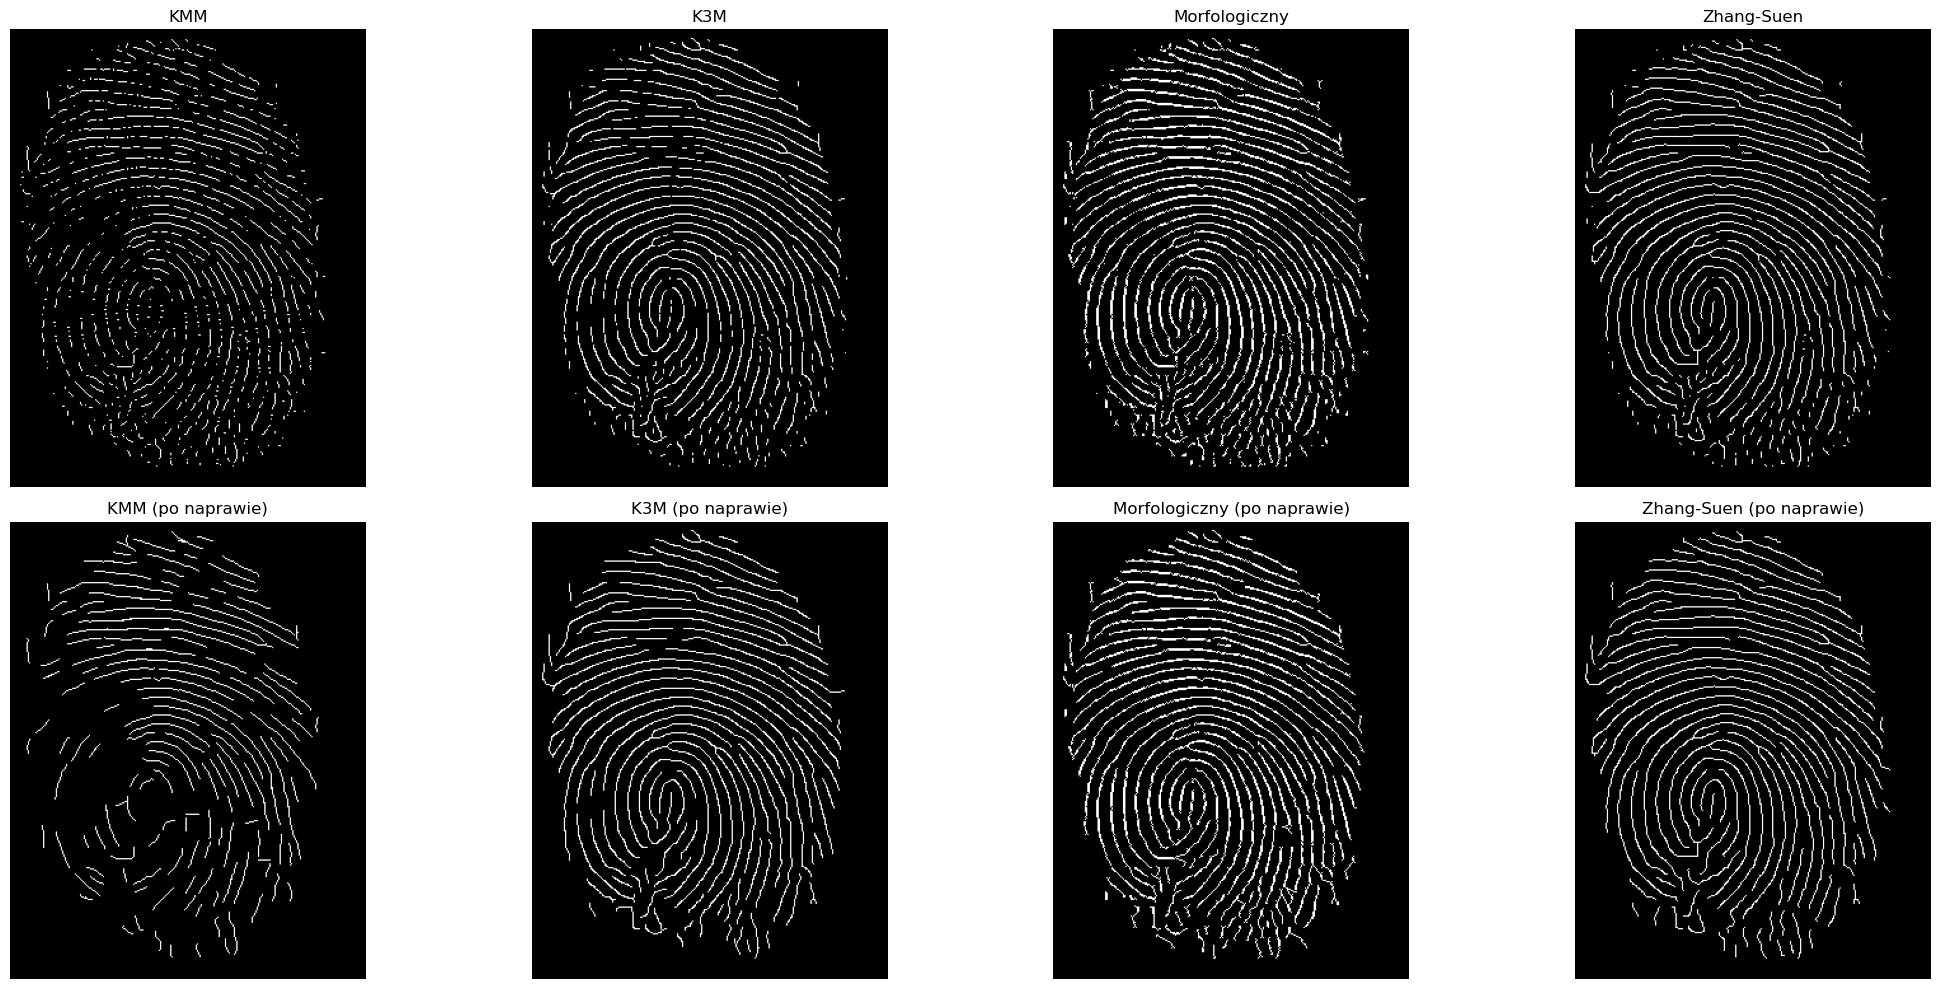

In [7]:
# Naprawa szkieletów — przekazujemy wersje 0/1, nie 0/255
sk_clean_kmm   = repairer.clean(sk_kmm_01,   min_length=10, max_distance=8)
sk_clean_k3m   = repairer.clean(sk_k3m_01,   min_length=10, max_distance=8)
sk_clean_morph = repairer.clean(sk_morph_01, min_length=10, max_distance=8)
sk_clean_zhang = repairer.clean(sk_zhang_01, min_length=10, max_distance=8)

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for ax, img, title in zip(axes[0],
        [sk_kmm_01, sk_k3m_01, sk_morph_01, sk_zhang_01],
        ['KMM', 'K3M', 'Morfologiczny', 'Zhang-Suen']):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
for ax, img, title in zip(axes[1],
        [sk_clean_kmm, sk_clean_k3m, sk_clean_morph, sk_clean_zhang],
        ['KMM (po naprawie)', 'K3M (po naprawie)',
         'Morfologiczny (po naprawie)', 'Zhang-Suen (po naprawie)']):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()



## Detekcja minucji

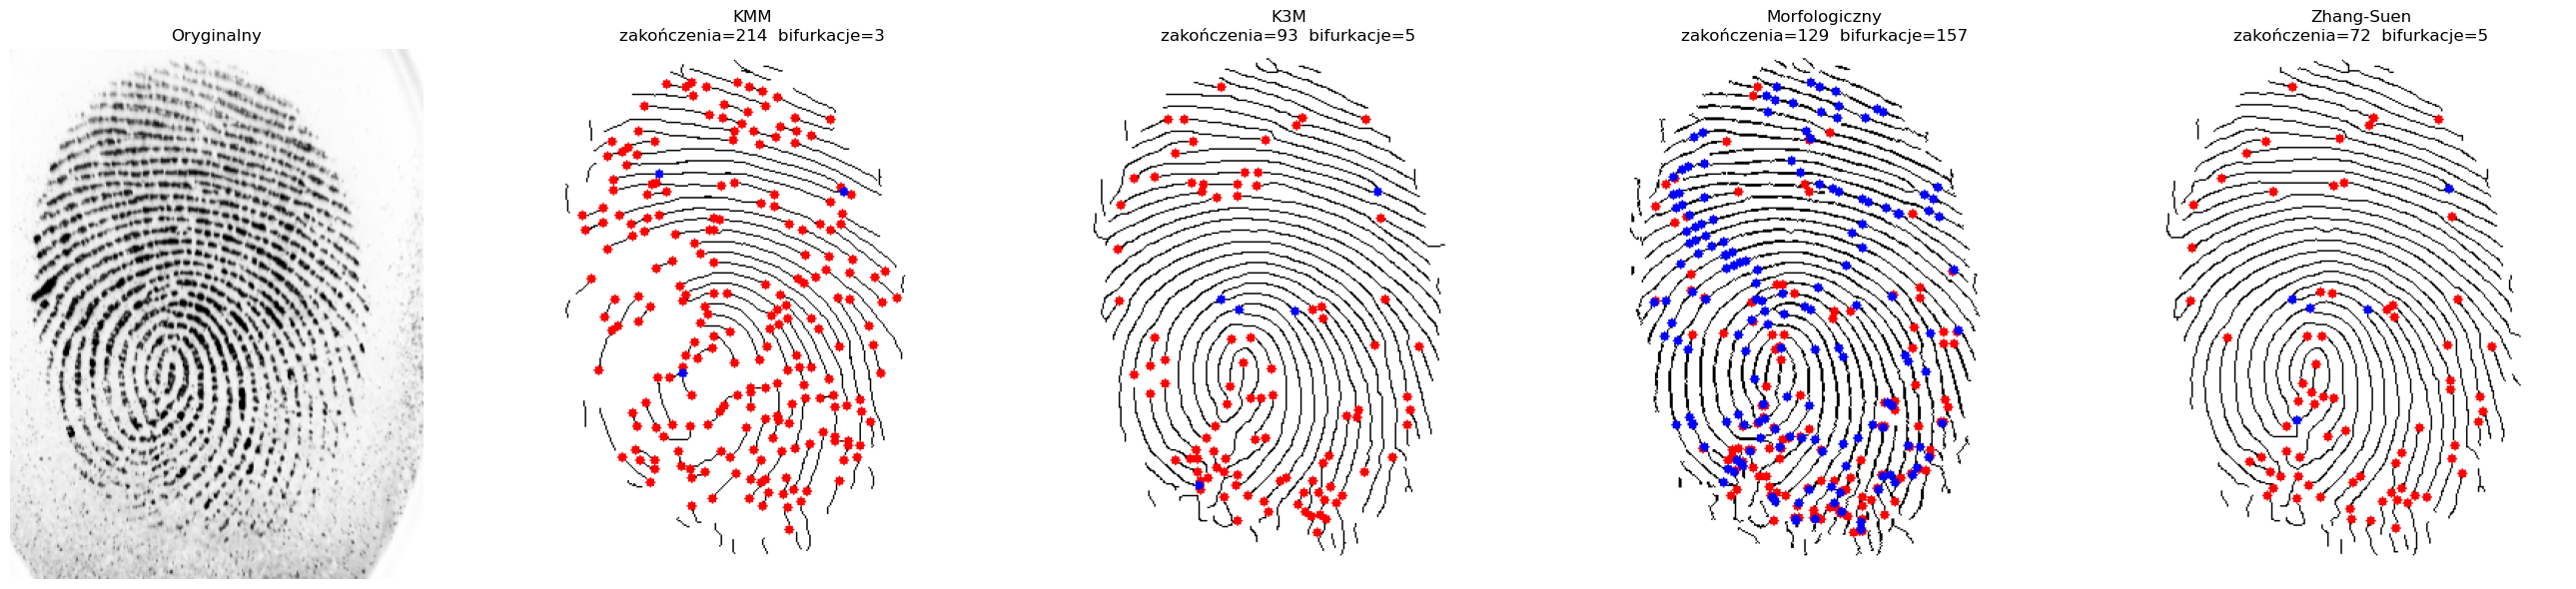

In [8]:
variants = [
    ('KMM',           sk_clean_kmm),
    ('K3M',           sk_clean_k3m),
    ('Morfologiczny',  sk_clean_morph),
    ('Zhang-Suen',    sk_clean_zhang),
]

fig, axes = plt.subplots(1, 5, figsize=(27, 6))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Oryginalny')
axes[0].axis('off')

# Pozostałe — minucje dla każdego wariantu
for ax, (title, skeleton) in zip(axes[1:], variants):
    endings, bifurcations = extractor.detect(skeleton, mask, erosions=15)
    vis = extractor.draw(skeleton, endings, bifurcations, radius=3)

    ax.imshow(vis)
    ax.set_title(f'{title}\nzakończenia={len(endings)}  bifurkacje={len(bifurcations)}')
    ax.axis('off')

plt.tight_layout()
plt.show()